In [1]:
import math
import csv
import numpy as np
import matplotlib.pyplot as plt
from math import e
import statistics as st
import cmath
import scipy
import scipy.stats as ss
import random
import seaborn as sns
import pandas as pd
import pyswarms
import emcee
import corner

In [2]:
data = map(lambda x: [ x[0], x[1], x[2] ],
        np.loadtxt("/Users/gopipatel/Documents/RRI_VSP/saras3_S11_200mm_above_water.s1p", skiprows=5))
d=list(data) #List of the format [Frequency, Magnitude, Phase (in degrees)]

In [3]:
c=3*10**8  # speed of light (m/s)
freq=[d[i][0] for i in range(len(d))] #frequency

In [4]:
def Compute_Tmeas_(PA, gamma_A, PN, gamma_N, f, l): 
    A=0
    B=0
    C=0
    l=l
    itr=3
    Tmeas=[]
    phi_A=0
    phi_N=0
    phi_f=0
    P_ref=300
    
    l=l
    freq= [d[i][0] for i in range(len(d))]
    for i in range(len(freq)):
        
        phi= (4*math.pi*(freq[i])*l)/(0.7*c)
        A=sum((abs(gamma_A)**k)*(abs(gamma_N)**k)*sum(math.cos((2*l-k)*(phi_N+phi_A+phi))for l in range(k+1)) for k in range(itr))   
        
        B=sum(2*abs(f)*(abs(gamma_A)**(o+1))*(abs(gamma_N)**o)*math.cos(phi_f+(o+1)*(phi_A+phi)+o*phi_N) for o in range(itr))
    
        C=sum((abs(gamma_A)**b)*(abs(gamma_N)**b)*sum(math.cos((2*c-b)*(phi_N+phi_A+phi)) for c in range(b+1)) for b in range(itr))
        
        Tmeas.append((PA*A-P_ref)+PN*(B+(abs(f)**2)*(abs(gamma_A)**2)*C))
    return(Tmeas)

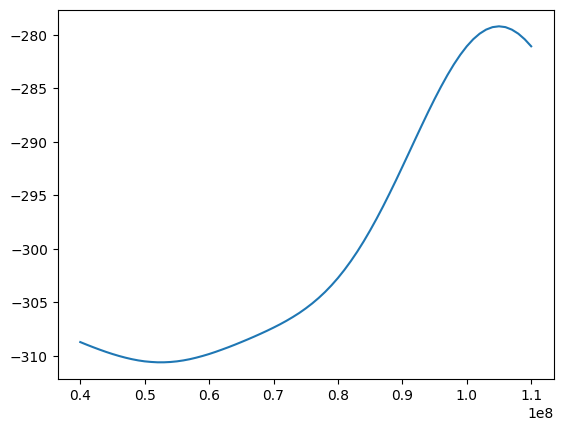

In [6]:
#Parameters
'''
PA  -------> Power at the Antenna terminal, can be open, short, load, and sky
PN  -------> Noise Power of the LNA in K 
P_ref  ----> Noise power from reference, considered to be ambient temperature
f ---------> Corr factor between the fwd and bkwd of the LNA, complex qty
gamma_A ---> Reflection Coeff. at the open terminal in db - Open
gamma_N ---> Reflection Coeff. at the LNA i/p (gamma N):10db
phi_A  ----> Phase of the wave reflected at the open terminal
phi_N  ----> phase of the noise wave
phi_f  ----> phase of the corr factor
'''

#simulated Tmeas

ip_params1=[0,1,70,0.3,0.1,1]   #PA, gamma_A, PN, gamma_N, f, l for open termination
ip_params2=[300,0,70,0.3,0.1,1] #PA, gamma_A, PN, gamma_N, f, l for open termination
TA_exp1=Compute_Tmeas_(*ip_params1)+np.random.normal(0,0.001,len(freq)) #adding Gaussian Noise
TA_exp2=Compute_Tmeas_(*ip_params2)+np.random.normal(0,0.001,len(freq)) #adding Gaussian Noise
plt.plot(freq,TA_exp1+TA_exp2)

In [8]:
def evolve_MCMC(ip_params, nsteps, initial_value):# Define parameter names
    
    parameter_names = ["PAo", "gamma_Ao", "PAl", "gamma_Al", "PN", "gamma_N", "f","l"]
    
    # Define bounds for parameters
    min_values = [0.0, 0.0, 0.0, 0.0, 50.0, 0.0, 0.05,0.05]
    max_values = [5.0, 1.0, 500, 1.0, 150.0, 1.0, 0.5, 5]
    #if type=='open' or type=='short':
        #max_values= [5, 1, 150, 1, 0.5, 5] 

    # Define the Expected TA values
    Po, gAo, Pl, gAl, Pn, gN, f, l = ip_params
    TA_exp_o = Compute_Tmeas_(Po, gAo, Pn, gN, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp_l = Compute_Tmeas_(Pl, gAl, Pn, gN, f, l) + np.random.normal(0,0.001,len(freq))  # Expected TA values
    TA_exp_o=np.array(TA_exp_o)
    TA_exp_l=np.array(TA_exp_l)
    
    ########## Define the log-likelihood function
    def log_likelihood(params):
        PAo, gamma_Ao, PAl, gamma_Al, PN, gamma_N, f, l = params
    
        # Compute model TA
        TA_model_o = Compute_Tmeas_(PAo, gamma_Ao, PN, gamma_N, f,  l) + np.random.normal(0,0.001,len(freq))
        TA_model_l = Compute_Tmeas_(PAl, gamma_Al, PN, gamma_N, f,  l) + np.random.normal(0,0.001,len(freq))
        TA_model_o=np.array(TA_model_o)
        TA_model_l=np.array(TA_model_l)
        # Compute chi-squared with weights
        s = 0.001  # Uncertainty
        chi2_o= np.sum([((TA_exp_o - TA_model_o)/s)** 2 ]) 
        chi2_l= np.sum([((TA_exp_l - TA_model_l)/s)** 2 ]) 
        return -0.5*chi2_o-0.5*chi2_l-2*np.log(math.sqrt(2*np.pi)*s) # Likelihood function
    
    ########## Define the log-prior function
    def log_prior(params):
        
        PAo, gamma_Ao, PAl, gamma_Al, PN, gamma_N, f, l = params
        """
        # Check if params are within bounds
        if 0.0 < PA < 5 and 0.0 < gamma_A < 1.0 and 5.0 < PN < 100.0 and 0.0 < gamma_N < 1.0 and 0.05 < f < 0.9 and 0.1 < l < 1.0:
            return 0.0
        return -np.inf
        """
    
        
        for p, min_v, max_v in zip(params, min_values, max_values):
            if not (min_v <= p <= max_v):
                return -np.inf  # Reject sample
        return 0.0  # Uniform prior
        
    
    ######### Define the full log-probability function
    
    def log_probability(params):
        lp = log_prior(params)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(params)
    
    # Number of walkers and steps
    ndim = 8  # Number of parameters
    nwalkers = 150  # Number of MCMC walkers
    nsteps = nsteps  # Number of MCMC steps per walker
    
    # Initialize walkers around a random point in parameter space
    #initial = np.array([np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)])
    
    #initial = np.array([[np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)] for _ in range(nwalkers)])
    initial_value=np.array(initial_value)
    
    ########## Starting positions for the walkers
    #pos = initial 
    #pos= initial_exact+ 1e-1*np.array([[np.random.uniform(pm,(1+1e-1)*pm) for pm in inp_params] for _ in range(nwalkers)])
    pos= initial_value + 1e-1*np.random.randn(nwalkers, ndim) #initial_exact[None,:]*
    #ind_pos = pos<0
    #pos[ind_pos] = np.abs(1e-1*np.random.randn(nwalkers, ndim))

    for idim in range(ndim):
        ind_pos = pos[:,idim]<0
        pos[ind_pos,idim] = np.abs(pos[ind_pos,idim])
    
    #pos= initial_exact+ 1e-1*np.array([[np.random.uniform(min_v, max_v) for min_v, max_v in zip(min_values, max_values)] for _ in range(nwalkers)]) 
    
    ############ Set up the MCMC sampler
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, threads=10)
    
    ############ Run MCMC
    print("Running MCMC...")
    sampler.run_mcmc(pos, nsteps, progress=True)
    
    ############ Extract the samples
    #samples = sampler.flatchain
    full_samples=sampler.get_chain()
    samples = sampler.get_chain(discard=0, thin=10, flat=True)

    ######### Compute log-likelihoods for all samples
    log_likes = np.array([log_likelihood(p) for p in samples])
    
    ######### Find the index of the maximum likelihood
    max_likelihood_index = np.argmax(log_likes)
    
    ########## Get the best-fit parameters
    best_fit_params = samples[max_likelihood_index].tolist()

    return full_samples,samples,best_fit_params

In [ ]:
#evolve MCMC
ip_params=[0, 1, 300, 0, 70, 0.3, 0.1, 1] #PAo, gamma_Ao, PAl, gamma_Al, PN, gamma_N, f, l
#initials=result.x #input parameters
initials=[0, 1, 300, 0, 70, 0.3, 0.1, 1]
#initials=[0.0008, 1.0, 290.00, 0, 70.07, 0.2990, 0.0998, 0.999]
chains=3
nsteps=3000

full_samples, samples, best_fit_params= evolve_MCMC(ip_params,nsteps=nsteps, initial_value=initials)

Running MCMC...


  0%|                                                  | 0/3000 [00:00<?, ?it/s]/Users/gopipatel/my_env/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
 68%|██████████████████████████▍            | 2036/3000 [06:06<03:11,  5.04it/s]

2025-03-25 17:02:32,046 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,070 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,086 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,109 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,123 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,138 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,164 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,181 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,196 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,211 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,237 - root - WARNING - Too few points to create valid contours
2025-03-25 17:02:32,253 - root - WARNING - Too few points to create valid contours
2025

Best-fit parameters (Maximum Likelihood Estimate): [0.05206156214878702, 0.4092517065623537, 300.0004707112852, 1.2413114859458062e-06, 75.79882524048442, 0.7331431472164475, 0.22564927307152666, 0.4999395942183673]


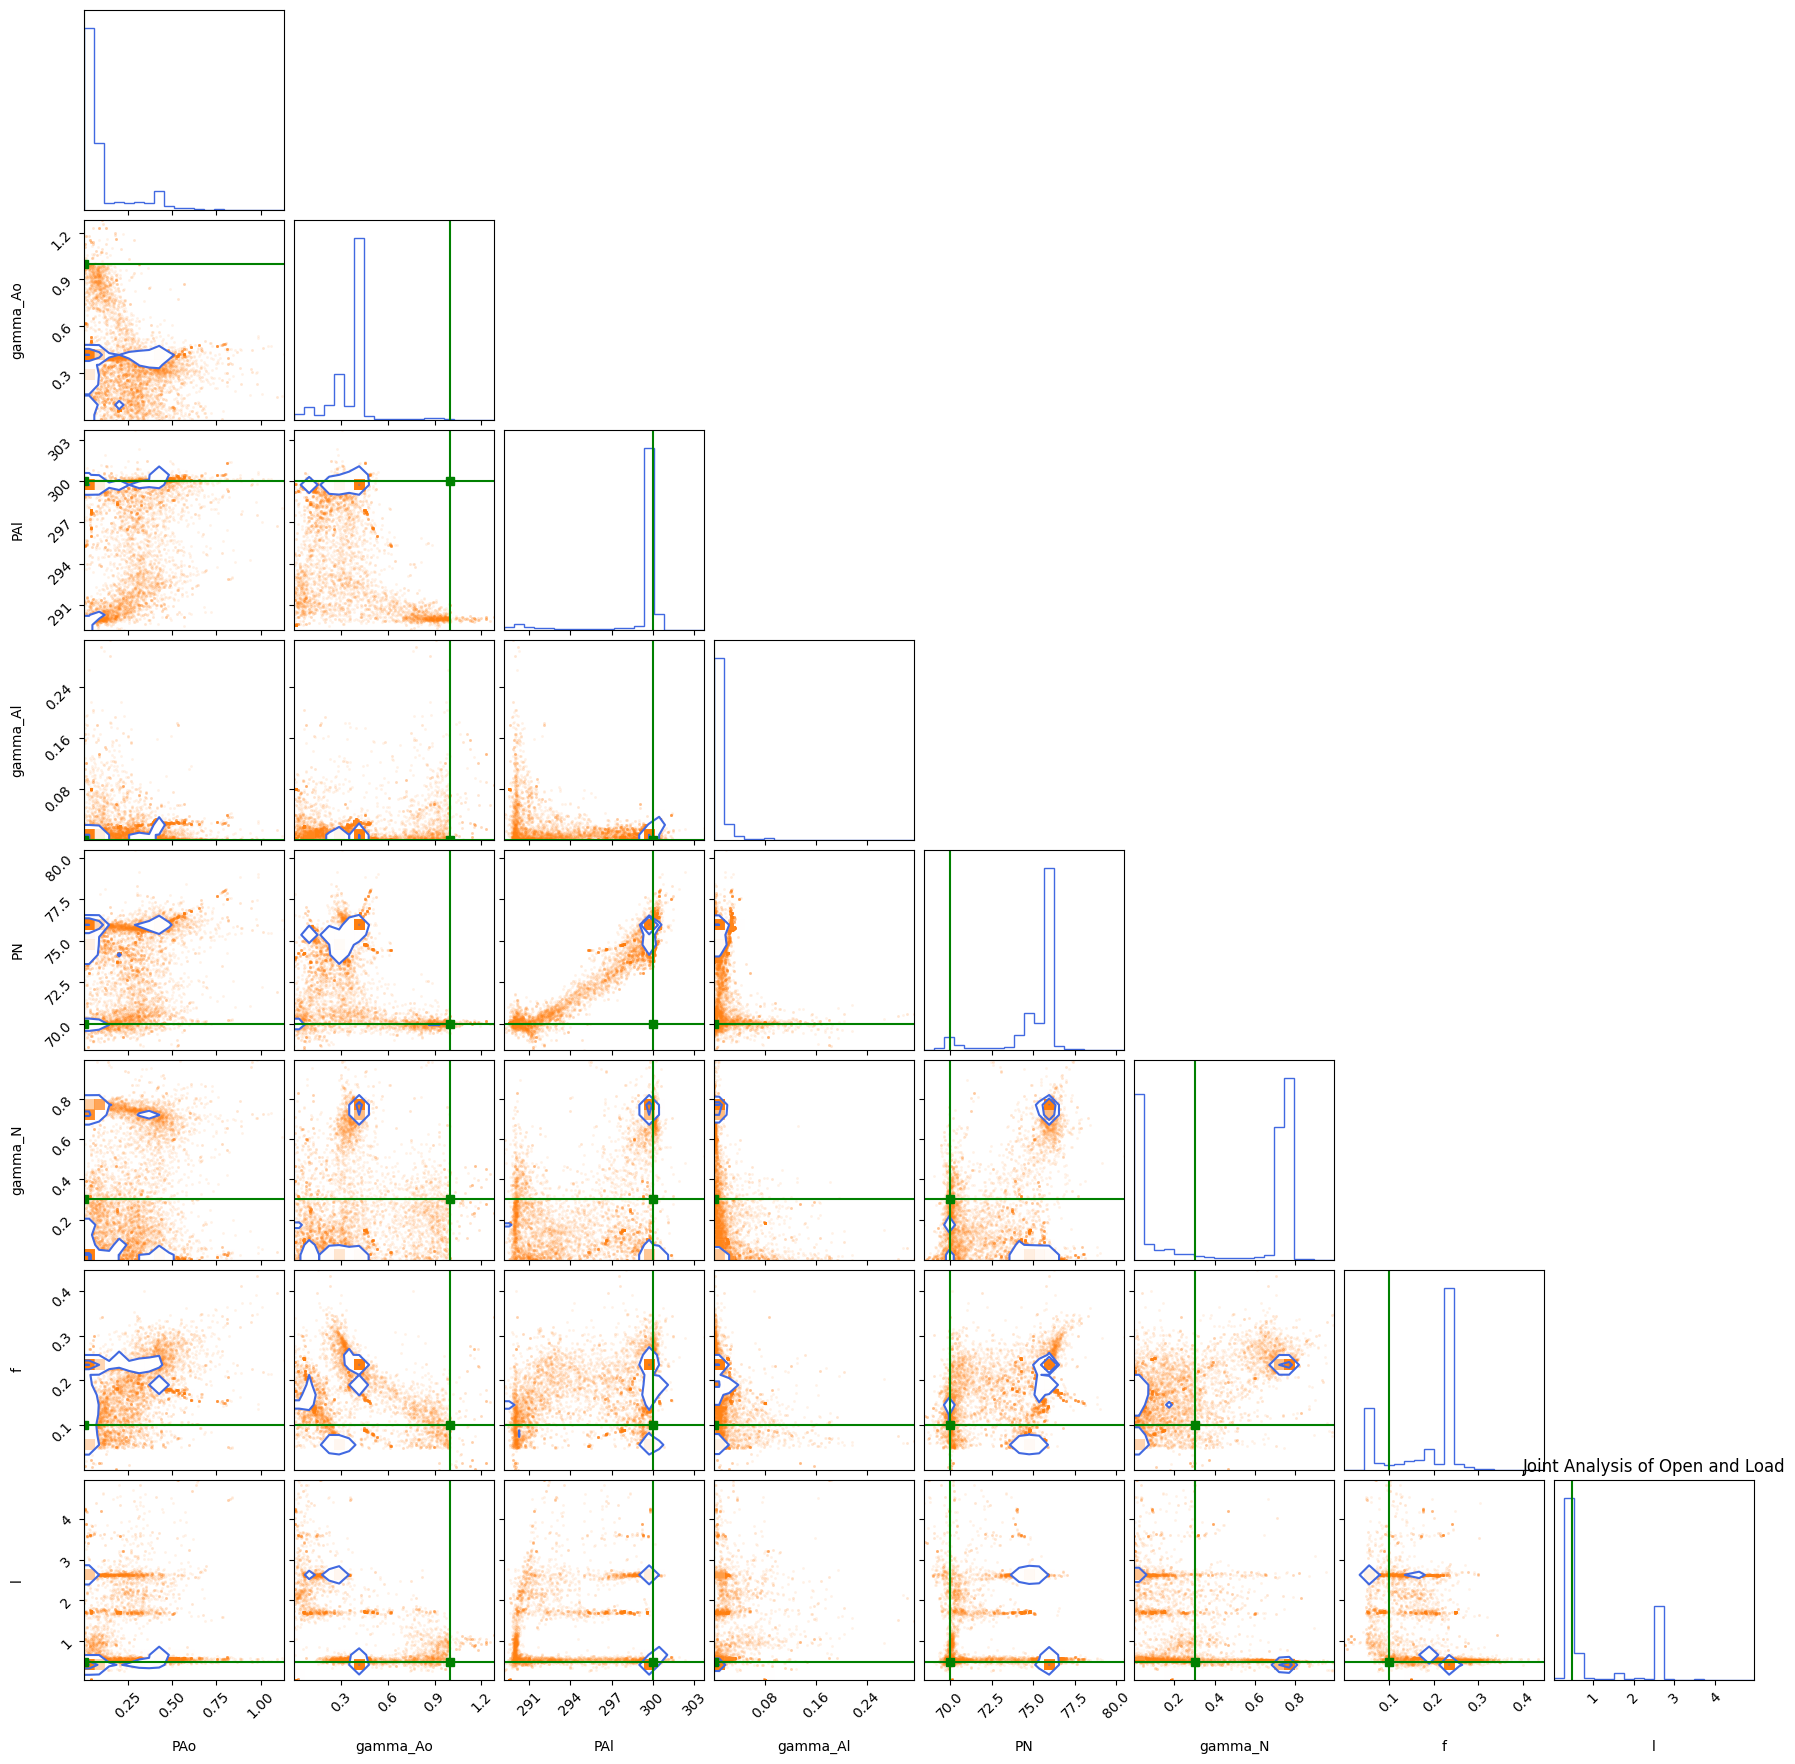

In [27]:
#corner plot
parameter_names = ["PAo", "gamma_Ao", "PAl", "gamma_Al", "PN", "gamma_N", "f","l"]
fig = corner.corner(samples, labels=parameter_names, truths=ip_params, color='C1',  # Change color of the contour and histograms
hist_kwargs={"color": "royalblue"},  # Set histogram color
contour_kwargs={"colors": ["royalblue"]},  # Set contour color
truth_color="green" ) # Color for the true parameter values)
plt.title("Joint Analysis of Open and Load")
plt.savefig('/Users/gopipatel/Desktop/MCMC_Joint.png', dpi=300)
#plt.show()

#print("Expected Paramerters:",ip_params)
print("Best-fit parameters (Maximum Likelihood Estimate):", best_fit_params)